# Human Recognition Activity


In [1]:
import pandas as pd


master = pd.read_csv('./data/S029.csv', usecols=['back_x','back_y','back_z','thigh_x','thigh_y','thigh_z','label'])

In [2]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 178716 entries, 0 to 178715
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   back_x   178716 non-null  float64
 1   back_y   178716 non-null  float64
 2   back_z   178716 non-null  float64
 3   thigh_x  178716 non-null  float64
 4   thigh_y  178716 non-null  float64
 5   thigh_z  178716 non-null  float64
 6   label    178716 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 9.5 MB


-> Debido al tamanio masivo del dataset, solo se utilizaran 50,000 registros

In [3]:
master = master[0:10000]

## Como se van a evaluar?
Se van a tomar en cuenta 4 metricas clave:
* Trustworthiness -> Mide qué tan bien se preserva la estructura local original al evitar que puntos lejanos en el espacio de alta dimensión se conviertan falsamente en vecinos cercanos en el espacio de baja dimensión.

* Silhouette -> Mide qué tan limpios y separados están los grupos de datos en un espacio geométrico

* Tiempo -> Mide el tiempo de ejecucion

* Metrica especifica -> A cada algoritmo se le puede evaluar con una metrica unica especifica, la cual no es intercambiable con los demas, la metrica a usar en cada uno es:
    * PCA -> Variance Ratio. Muestra cuanta varianza contienen las nuevas dimensiones con respecto de los datos originales
    * Random Projection -> Reconstrucion error. Mide cuánta información o estructura espacial se pierde cuando reduces las dimensiones de un conjunto de datos, es decir, qué tan bien se pueden "reconstruir" o aproximar los datos originales a partir de su versión simplificada.
    * t-sne -> KL Divergence. Es la función de coste o pérdida que mide qué tan distinta es la distribución de probabilidad de los puntos en el espacio original de alta dimensión en comparación con el espacio reducido de baja dimensión. Va de 1 a 0. Es decir, si la divergencia es cero, las distribuciones son identicas.
    * fastICA -> No hay metrica es especifico para evaluar esta transformacion.


In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np

x = master.drop(columns=['label'])
y = master['label']

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [5]:
import matplotlib.pyplot as plt

# Funcion para graficar una reducción 3D
def plot_3d(X_reduced, y, title):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        X_reduced[:, 0],
        X_reduced[:, 1],
        X_reduced[:, 2],
        c=y,
        cmap="viridis",
        s=20,
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    ax.set_zlabel("Componente 3")

    fig.colorbar(
        scatter,
        ax=ax,
        label="Clase"
    )

    plt.show()

## PCA

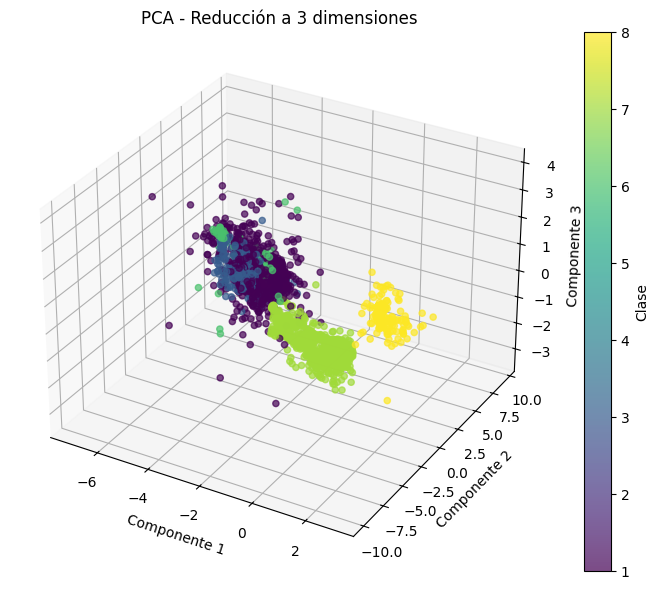

In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from time import perf_counter

start = perf_counter()

pca = PCA(n_components=3)
X_pca = pca.fit_transform(x_scaled)

time_pca = perf_counter() - start

trust_pca = trustworthiness(
    x_scaled,
    X_pca,
    n_neighbors=5
)

sil_pca = silhouette_score(
    X_pca,
    y
)

variance_pca = pca.explained_variance_ratio_.sum()

plot_3d(
    X_pca,
    y,
    "PCA - Reducción a 3 dimensiones"
)



## Random Projection


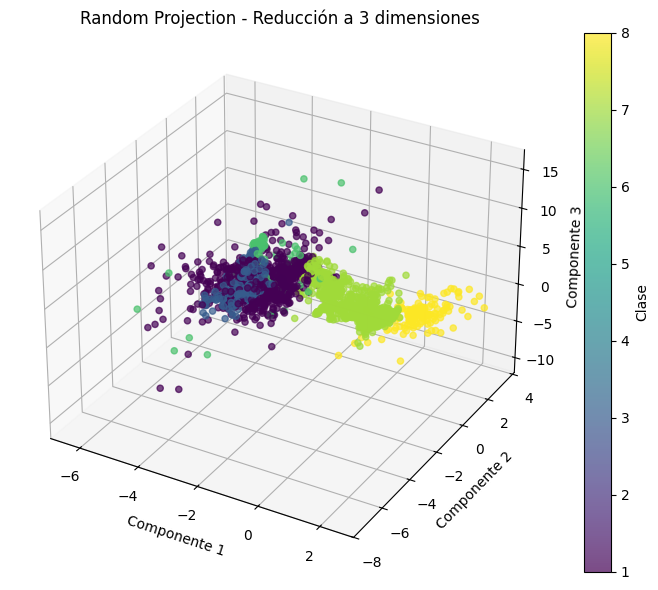

In [7]:
from sklearn.random_projection import GaussianRandomProjection

start = perf_counter()

rp = GaussianRandomProjection(
    n_components=3,
    random_state=42
)

X_rp = rp.fit_transform(x_scaled)

time_rp = perf_counter() - start

trust_rp = trustworthiness(
    x_scaled,
    X_rp,
    n_neighbors=5
)

sil_rp = silhouette_score(
    X_rp,
    y
)

X_rp_reconstructed = rp.inverse_transform(X_rp)

reconstruction_error_rp = np.mean(
    (x_scaled - X_rp_reconstructed) ** 2
)

plot_3d(
    X_rp,
    y,
    "Random Projection - Reducción a 3 dimensiones"
)


## t-SNE

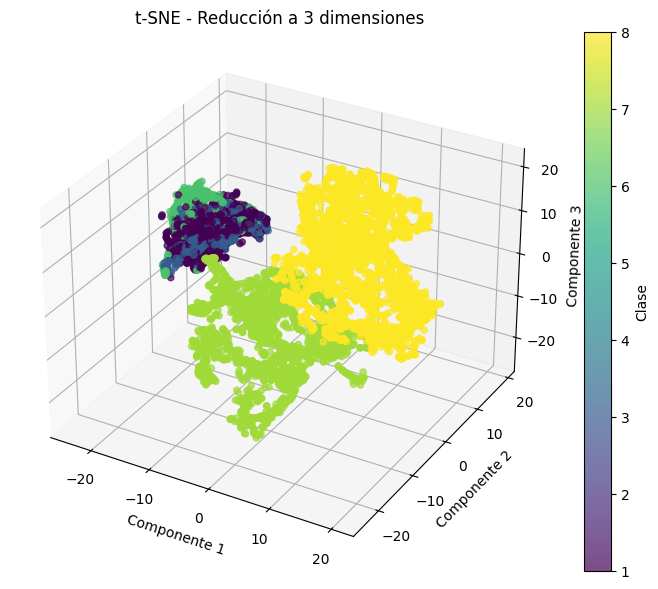

In [8]:
from sklearn.manifold import TSNE

start = perf_counter()

tsne = TSNE(
    n_components=3,
    random_state=42,
    perplexity=50,
    n_jobs=-1
)

X_tsne = tsne.fit_transform(x_scaled)

time_tsne = perf_counter() - start

trust_tsne = trustworthiness(
    x_scaled,
    X_tsne,
    n_neighbors=5
)

sil_tsne = silhouette_score(
    X_tsne,
    y
)



plot_3d(
    X_tsne,
    y,
    "t-SNE - Reducción a 3 dimensiones"
)

## fastICA

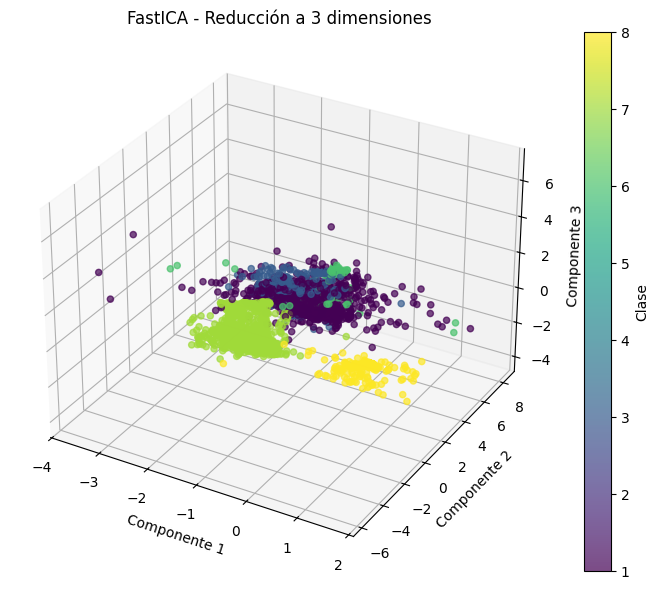

In [9]:
from sklearn.decomposition import FastICA

start = perf_counter()

ica = FastICA(
    n_components=3,
    random_state=42,
    max_iter=1000
)

X_ica = ica.fit_transform(x_scaled)

time_ica = perf_counter() - start

trust_ica = trustworthiness(
    x_scaled,
    X_ica,
    n_neighbors=5
)

sil_ica = silhouette_score(
    X_ica,
    y
)

X_ica_reconstructed = ica.inverse_transform(X_ica)

reconstruction_error_ica = np.mean(
    (x_scaled - X_ica_reconstructed) ** 2
)

plot_3d(
    X_ica,
    y,
    "FastICA - Reducción a 3 dimensiones"
)

## Resultados

In [10]:
results = pd.DataFrame({
    "Algorithm": [
        "PCA",
        "Random Projection",
        "t-SNE",
        "FastICA"
    ],
    "Trustworthiness": [
        trust_pca,
        trust_rp,
        trust_tsne,
        trust_ica
    ],
    "Silhouette": [
        sil_pca,
        sil_rp,
        sil_tsne,
        sil_ica
    ],
    "Tiempo": [
        time_pca,
        time_rp,
        time_tsne,
        time_ica
    ],
    "Variance_ratio": [
        variance_pca,
        np.nan,
        np.nan,
        np.nan
    ],
    "Reconstruction_Error": [
            np.nan,
            reconstruction_error_rp,
            np.nan,
            np.nan
    ],
    "KL_Divergence": [
                np.nan,
                np.nan,
                tsne.kl_divergence_,
                np.nan
    ]
})

results

,Algorithm,Trustworthiness,Silhouette,Tiempo,Variance_ratio,Reconstruction_Error,KL_Divergence
0,PCA,0.984954,0.621669,0.004304,0.852054,NaN,NaN
1,Random Projection,0.984320,0.501293,0.003312,NaN,0.441562,NaN
2,t-SNE,0.998711,0.206567,130.389573,NaN,NaN,0.635097
3,FastICA,0.984533,0.628265,0.016349,NaN,NaN,NaN


In [11]:
results[['Algorithm', 'Trustworthiness', 'Silhouette', 'Tiempo']]

,Algorithm,Trustworthiness,Silhouette,Tiempo
0,PCA,0.984954,0.621669,0.004304
1,Random Projection,0.984320,0.501293,0.003312
2,t-SNE,0.998711,0.206567,130.389573
3,FastICA,0.984533,0.628265,0.016349


In [13]:
results[['Algorithm','Variance_ratio','Reconstruction_Error','KL_Divergence']]

,Algorithm,Variance_ratio,Reconstruction_Error,KL_Divergence
0,PCA,0.852054,NaN,NaN
1,Random Projection,NaN,0.441562,NaN
2,t-SNE,NaN,NaN,0.635097
3,FastICA,NaN,NaN,NaN


In [14]:
print(results)

           Algorithm  Trustworthiness  Silhouette      Tiempo  Variance_ratio  \
0                PCA         0.984954    0.621669    0.004304        0.852054   
1  Random Projection         0.984320    0.501293    0.003312             NaN   
2              t-SNE         0.998711    0.206567  130.389573             NaN   
3            FastICA         0.984533    0.628265    0.016349             NaN   

   Reconstruction_Error  KL_Divergence  
0                   NaN            NaN  
1              0.441562            NaN  
2                   NaN       0.635097  
3                   NaN            NaN  


## Conclusiones
